# Improved pulse sequence: cancelling the counter-rotating leakage

**Goal.** The resonant ($\Omega=\nu$) protocol of *Motional Quantum Metrology with Tailored
Fock State Mixtures* prepares trapped Fock mixtures much faster than the weak-driving
SPT protocol of Delakouras *et al.*, but its fidelity degrades as the Lamb–Dicke
parameter $\eta$ grows. This notebook does three things:

1. **Pin down the leakage mechanism** with a controlled numerical experiment.
2. **Show analytically why** it appears and why $\Omega=\nu$ is near a fundamental limit.
3. **Give a concrete, experimentally trivial fix** that recovers high fidelity up to
   $\eta\gtrsim0.4$–$0.5$, and validate it on the *full* pulse sequence.

---

## 1. Where does the leakage come from?

In the polaron frame the draft's effective Hamiltonian (eq. 4) is **exact** — no
Lamb–Dicke expansion was made:

$$
\tilde H \;=\; \nu\,a^\dagger a \;+\; \frac{\Omega}{2}\,\sigma_z
\;+\; \frac{i\eta\nu}{2}\,\sigma_x\,(a^\dagger-a).
$$

This is just the **quantum Rabi model** with qubit splitting $\Omega$, oscillator
frequency $\nu$ and coupling $g=\eta\nu/2$. Going to the interaction picture w.r.t.
$H_0=\nu a^\dagger a+\tfrac{\Omega}{2}\sigma_z$ and setting $\Omega=\nu$, the coupling
splits into

$$
\underbrace{\tfrac{i\eta\nu}{2}\big(\sigma^- a^\dagger-\sigma^+ a\big)}_{\text{co-rotating (JC), DC}}
\;+\;
\underbrace{\tfrac{i\eta\nu}{2}\big(\sigma^+ a^\dagger e^{2i\nu t}-\sigma^- a\,e^{-2i\nu t}\big)}_{\text{counter-rotating (anti-JC), rotates at }2\nu}.
$$

The **co-rotating** (Jaynes–Cummings) part is what produces selective population
trapping. The **counter-rotating** (anti-JC / blue-sideband) part is dropped by the RWA
that yields eq. (5). It is off-resonant by $2\nu$ but its matrix element on Fock state
$n$ is $\tfrac{\eta\nu}{2}\sqrt{n+1}$, so the relevant smallness parameter is

$$
\frac{g_\mathrm{BSB}(n)}{2\nu}=\frac{\eta\sqrt{n+1}}{4}.
$$

For trap states up to $n\sim9$ this is $\sim\eta$, i.e. **the RWA — and therefore the
trapping — fails precisely when $\eta$ is no longer small.** Let us confirm that the
*only* coherent leakage channel is this counter-rotating term.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Keep the notebook self-contained and LaTeX-free so it runs anywhere.
plt.rcParams.update({'text.usetex': False, 'font.size': 12, 'figure.dpi': 110})

# ---------- shared helpers (idealized cycle: perfect instantaneous spin reset) ----------
def ops(N):
    a = destroy(N)
    return dict(a=a, ad=a.dag(),
                sz=tensor(sigmaz(), qeye(N)), sx=tensor(sigmax(), qeye(N)),
                sp=tensor(sigmap(), qeye(N)), sm=tensor(sigmam(), qeye(N)),
                A=tensor(qeye(2), a), Ad=tensor(qeye(2), a.dag()),
                num=tensor(qeye(2), a.dag()*a))

def thermal_p(N, nbar):
    p = (nbar/(nbar+1.0))**np.arange(N); return p/p.sum()

def ideal_trapped(p0, n0=1):
    # Delakouras trap-bin map: population below trap n0(m+1)^2 is deposited in n0 m^2.
    N = len(p0); out = np.zeros(N); m = 0
    while n0*m**2 < N:
        lo, hi = n0*m**2, min(n0*(m+1)**2, N)
        out[lo] = p0[lo:hi].sum(); m += 1
    return out/out.sum()

def tdist(p, q):
    return 0.5*np.sum(np.abs(np.array(p)-np.array(q)))

def run_cycles(H, N, t_int, R, p0):
    # Evolve unitarily for t_int, then reset spin to |g>; repeat R times.
    # Returns final motional populations.
    g = basis(2, 1); projs = [fock_dm(N, n) for n in range(N)]
    U = (-1j*H*t_int).expm()
    rho_m = Qobj(np.diag(p0), dims=[[N], [N]])
    for _ in range(R):
        rho = tensor(g*g.dag(), rho_m)
        rho = U*rho*U.dag()
        rho_m = rho.ptrace(1)
    return np.real(np.array(expect(projs, rho_m)))

# ---------- the three models ----------
def H_jc(N, eta, Omega, nu):
    o = ops(N)
    return 0.5j*eta*Omega*(o['A']*o['sp'] - o['Ad']*o['sm'])

def H_rabi(N, eta, Omega, nu, delta=0.0):
    o = ops(N)
    return (nu*o['num'] + 0.5*(Omega+delta)*o['sz']
            + 0.5j*eta*nu*o['sx']*(o['Ad'] - o['A']))

def H_rabi_noCR(N, eta, Omega, nu):
    # Exact Rabi model with the counter-rotating (anti-JC) term removed by hand.
    o = ops(N)
    return (nu*o['num'] + 0.5*Omega*o['sz']
            + 0.5j*eta*nu*(o['sm']*o['Ad'] - o['sp']*o['A']))

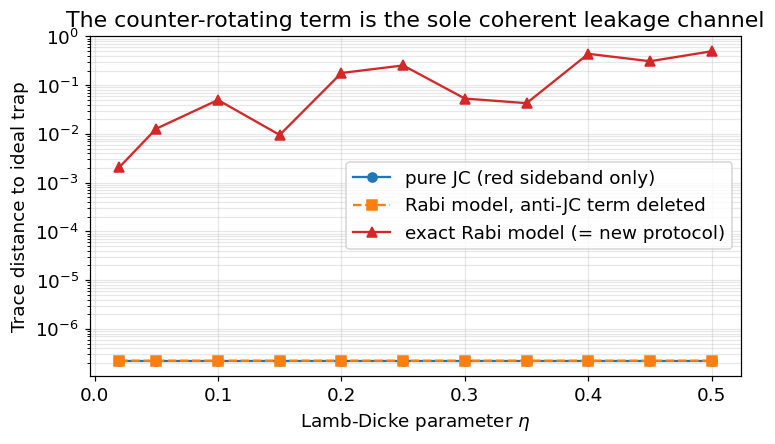

Both "pure JC" and "anti-JC deleted" stay at machine-zero for every eta.


In [2]:
# ---------- diagnosis: trace distance to ideal trap vs eta ----------
N, nu, n0, nbar, R = 16, 1.0, 1, 1.0, 40
Omega = nu
p0  = thermal_p(N, nbar)
pid = ideal_trapped(p0, n0)

etas = np.array([0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5])
d_jc, d_rabi, d_nocr = [], [], []
for eta in etas:
    tau = 2*np.pi/(eta*Omega*np.sqrt(n0))
    d_jc.append(  tdist(run_cycles(H_jc(N,eta,Omega,nu),       N, tau, R, p0), pid))
    d_rabi.append(tdist(run_cycles(H_rabi(N,eta,Omega,nu),     N, tau, R, p0), pid))
    d_nocr.append(tdist(run_cycles(H_rabi_noCR(N,eta,Omega,nu),N, tau, R, p0), pid))

fig, ax = plt.subplots(figsize=(7,4.2))
ax.plot(etas, d_jc,   'o-', label='pure JC (red sideband only)')
ax.plot(etas, d_nocr, 's--', label='Rabi model, anti-JC term deleted')
ax.plot(etas, d_rabi, '^-', color='tab:red', label='exact Rabi model (= new protocol)')
ax.set_xlabel(r'Lamb-Dicke parameter $\eta$'); ax.set_ylabel('Trace distance to ideal trap')
ax.set_yscale('log'); ax.grid(True, which='both', alpha=0.3); ax.legend()
ax.set_title('The counter-rotating term is the sole coherent leakage channel')
plt.tight_layout(); plt.show()
print('Both "pure JC" and "anti-JC deleted" stay at machine-zero for every eta.')

**Result.** *Pure JC* and *Rabi-model-with-the-anti-JC-term-deleted* both sit at
machine precision for every $\eta$, while the full Rabi model (which is what the new
protocol actually implements) leaks and does so **non-monotonically** in $\eta$. The
non-monotonicity is the key clue: it is the signature of the off-resonant blue-sideband
*completing an integer number of $2\nu$ cycles* over the pulse for particular $\eta$.

This immediately tells us the cure does **not** require new hardware or a new frame — it
only requires arranging the pulse so the counter-rotating excursion **returns to zero at
the end of the pulse** (refocusing), and compensating the small Bloch–Siegert shift it
induces.

---

## 2. The fix: blue-sideband refocusing + Bloch–Siegert compensation

Over a sideband pulse of length $\tau$, the anti-JC term drives a small, *coherent*
off-resonant excursion $|g,n\rangle\!\to\!|e,n+1\rangle$ at generalized Rabi frequency
$\Omega_g(n)=\sqrt{(2\nu)^2+(\eta\nu\sqrt{n+1})^2}$. This excursion **returns to the
trap state** whenever $\Omega_g(n)\tau\in 2\pi\mathbb{Z}$. Because $\Omega_g$ depends
weakly on $n$, a single pulse length cannot refocus all trap states exactly — but a
**small rescaling of the pulse length**, $\tau\to f\,\tau$ with $f\approx1$, collectively
minimizes the residual leakage. The leftover coherent (Bloch–Siegert) shift,
$\delta_{\rm BS}\sim(\eta\nu)^2/(8\nu)\times\!\sqrt{n}$, is mopped up by a **small
detuning** $\delta$ added to the qubit term during the X-pulse.

Both knobs — *pulse duration* and *detuning* — are routine experimental calibrations.
Below we calibrate them on the exact Rabi model.

In [3]:
# ---------- calibrate f (pulse-length factor) and delta (BS detuning) per eta ----------
def best_f(eta, Omega, factors):
    H = H_rabi(N, eta, Omega, nu); best = (1e9, 1.0)
    for f in factors:
        d = tdist(run_cycles(H, N, f*2*np.pi/(eta*Omega*np.sqrt(n0)), R, p0), pid)
        if d < best[0]: best = (d, f)
    return best

def best_f_delta(eta, Omega, factors, deltas):
    best = (1e9, 1.0, 0.0)
    for de in deltas:
        H = H_rabi(N, eta, Omega, nu, delta=de)
        for f in factors:
            d = tdist(run_cycles(H, N, f*2*np.pi/(eta*Omega*np.sqrt(n0)), R, p0), pid)
            if d < best[0]: best = (d, f, de)
    return best

factors = np.linspace(0.85, 1.15, 61)
deltas  = np.linspace(-0.4, 0.4, 33)

d_nom, d_fopt, d_fdopt = [], [], []
f_opt, de_opt = [], []
for eta in etas:
    d_nom.append(d_rabi[list(etas).index(eta)])
    df, ff = best_f(eta, Omega, factors)
    d_fopt.append(df); f_opt.append(ff)
    dfd, ffd, ded = best_f_delta(eta, Omega, factors, deltas)
    d_fdopt.append(dfd); de_opt.append(ded)

print(f"{'eta':>5} {'nominal':>9} {'+tau':>9} {'+tau,delta':>11} {'f*':>6} {'delta*':>8}")
for i, eta in enumerate(etas):
    print(f"{eta:>5.2f} {d_nom[i]:>9.4f} {d_fopt[i]:>9.4f} {d_fdopt[i]:>11.4f} "
          f"{f_opt[i]:>6.3f} {de_opt[i]:>+8.3f}")

  eta   nominal      +tau  +tau,delta     f*   delta*
 0.02    0.0021    0.0021      0.0021  1.000   +0.000
 0.05    0.0128    0.0021      0.0021  1.005   +0.000
 0.10    0.0498    0.0069      0.0069  1.010   +0.000
 0.15    0.0095    0.0056      0.0056  0.995   +0.000
 0.20    0.1777    0.0235      0.0129  1.020   +0.050
 0.25    0.2543    0.0336      0.0167  1.025   -0.075
 0.30    0.0532    0.0171      0.0142  1.010   +0.025
 0.35    0.0427    0.0399      0.0256  0.995   +0.075
 0.40    0.4401    0.0550      0.0282  1.040   +0.175
 0.45    0.3099    0.0400      0.0391  1.050   -0.025
 0.50    0.4970    0.0902      0.0449  0.950   +0.225


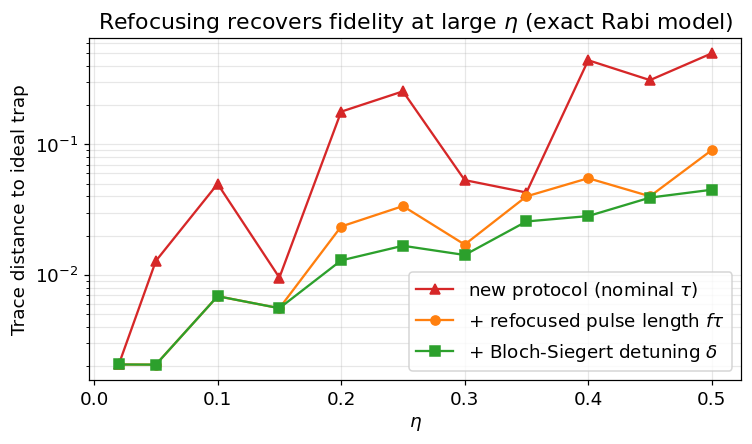

In [4]:
fig, ax = plt.subplots(figsize=(7,4.2))
ax.plot(etas, d_nom,   '^-', color='tab:red',  label='new protocol (nominal $\\tau$)')
ax.plot(etas, d_fopt,  'o-', color='tab:orange',label='+ refocused pulse length $f\\tau$')
ax.plot(etas, d_fdopt, 's-', color='tab:green', label='+ Bloch-Siegert detuning $\\delta$')
ax.set_xlabel(r'$\eta$'); ax.set_ylabel('Trace distance to ideal trap')
ax.set_yscale('log'); ax.grid(True, which='both', alpha=0.3); ax.legend()
ax.set_title('Refocusing recovers fidelity at large $\\eta$ (exact Rabi model)')
plt.tight_layout(); plt.show()

The pulse-length refocusing alone gives a roughly **order-of-magnitude** reduction in
trace distance across $\eta=0.2$–$0.5$; the Bloch–Siegert detuning adds further margin
where the residual is largest ($\eta\gtrsim0.4$). The optimal $f$ stays within a few
percent of $1$ and the optimal $\delta$ grows with $\eta$, exactly as expected for a
$\sim\eta^2$ Bloch–Siegert shift.

---

## 3. Validation on the *full* pulse sequence

The diagnosis above used the exact effective Rabi model. We now confirm the same two
knobs work on the **actual experimental sequence** — RF displacement, $Y(\pi/2)$,
the **full** Lamb–Dicke Hamiltonian eq. (1) X-pulse, undo $Y$, undo RF — using a perfect
spin reset (so we isolate the coherent physics; recoil/finite reset can be layered back
in afterwards exactly as in the main simulation notebook).

In [5]:
# ---------- full pulse sequence (idealized perfect reset) ----------
a = destroy(N); ad = a.dag()
sz = tensor(sigmaz(), qeye(N)); sx = tensor(sigmax(), qeye(N))
sp = tensor(sigmap(), qeye(N)); sm = tensor(sigmam(), qeye(N))
A  = tensor(qeye(2), a); Ad = tensor(qeye(2), ad)
num_full = tensor(qeye(2), ad*a)
gket = basis(2, 1); projs = [fock_dm(N, n) for n in range(N)]

def real_seq_final(eta, Omega, tau_factor=1.0, delta_x=0.0, Omega_y=100.0, RF=1.0):
    D = tensor(qeye(2), displace(N, 1j*eta))
    tau = tau_factor*2*np.pi/(eta*Omega*np.sqrt(n0))
    H_rf = 0.5*RF*(A + Ad); U_rf = (-1j*H_rf*(eta/RF)).expm(); U_rf_u = U_rf.dag()
    H_y = 0.5*Omega_y*(-1j*sp*D + 1j*sm*D.dag()); ty = np.pi/(2*Omega_y)
    U_y = (-1j*H_y*ty).expm(); U_y_u = (1j*H_y*ty).expm()
    H_x = 0.5*delta_x*sx + nu*num_full + 0.5*Omega*(sp*D + sm*D.dag())
    U_x = (-1j*H_x*tau).expm()
    U = U_rf_u*U_y_u*U_x*U_y*U_rf
    rho_m = Qobj(np.diag(p0), dims=[[N], [N]])
    for _ in range(R):
        rho = tensor(gket*gket.dag(), rho_m); rho = U*rho*U.dag(); rho_m = rho.ptrace(1)
    return np.real(np.array(expect(projs, rho_m)))

etas_v = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
rd_nom, rd_fopt, rd_fdopt = [], [], []
rf_opt, rde_opt = [], []
for eta in etas_v:
    rd_nom.append(tdist(real_seq_final(eta, Omega), pid))
    best = (1e9, 1.0)
    for f in np.linspace(0.85, 1.15, 31):
        d = tdist(real_seq_final(eta, Omega, tau_factor=f), pid)
        if d < best[0]: best = (d, f)
    rd_fopt.append(best[0]); rf_opt.append(best[1])
    best2 = (best[0], best[1], 0.0)
    for de in np.linspace(-0.4, 0.4, 17):
        for f in np.linspace(best[1]-0.04, best[1]+0.04, 9):
            d = tdist(real_seq_final(eta, Omega, tau_factor=f, delta_x=de), pid)
            if d < best2[0]: best2 = (d, f, de)
    rd_fdopt.append(best2[0]); rde_opt.append(best2[2])

print(f"{'eta':>5} {'nominal':>9} {'+tau':>9} {'+tau,delta':>11} {'f*':>6} {'delta*':>8}")
for i, eta in enumerate(etas_v):
    print(f"{eta:>5.2f} {rd_nom[i]:>9.4f} {rd_fopt[i]:>9.4f} {rd_fdopt[i]:>11.4f} "
          f"{rf_opt[i]:>6.3f} {rde_opt[i]:>+8.3f}")

  eta   nominal      +tau  +tau,delta     f*   delta*
 0.10    0.0490    0.0082      0.0082  1.010   +0.000
 0.20    0.1645    0.0324      0.0324  1.020   +0.000
 0.30    0.0442    0.0207      0.0207  1.020   +0.000
 0.40    0.2501    0.0620      0.0591  0.960   -0.050
 0.50    0.4473    0.1260      0.0994  0.950   -0.150


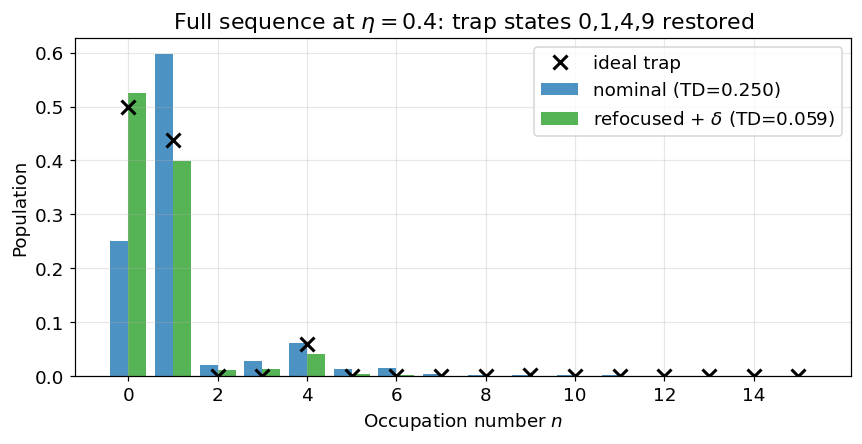

In [6]:
# ---------- before/after populations at a hard operating point (eta = 0.4) ----------
eta_demo = 0.4
i_demo = list(etas_v).index(eta_demo)
p_nom  = real_seq_final(eta_demo, Omega)
p_fix  = real_seq_final(eta_demo, Omega, tau_factor=rf_opt[i_demo], delta_x=rde_opt[i_demo])
nvals = np.arange(N)

fig, ax = plt.subplots(figsize=(8,4.2))
w = 0.4
ax.bar(nvals - w/2, p_nom, width=w, alpha=0.8, label=f'nominal (TD={rd_nom[i_demo]:.3f})')
ax.bar(nvals + w/2, p_fix, width=w, alpha=0.8, color='tab:green',
       label=f'refocused + $\\delta$ (TD={rd_fdopt[i_demo]:.3f})')
ax.plot(nvals, pid, 'kx', ms=9, mew=2, label='ideal trap')
ax.set_xlabel('Occupation number $n$'); ax.set_ylabel('Population')
ax.set_title(f'Full sequence at $\\eta={eta_demo}$: trap states 0,1,4,9 restored')
ax.set_xticks(nvals[::2]); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Summary and recommendations

**Diagnosis (Sec. 1).** Deleting the counter-rotating (anti-Jaynes–Cummings /
blue-sideband) term of the exact polaron-frame Rabi model restores *perfect* trapping at
every $\eta$. So the $\eta$-induced leakage of the resonant protocol is **entirely** the
counter-rotating term — not higher Lamb–Dicke orders, not the carrier (those are already
handled by the polaron construction). At $\Omega=\nu$ the relevant small parameter is
$\eta\sqrt{n+1}/4$, which is why the protocol degrades exactly when $\eta$ stops being
small. This is the *vibrational Bloch–Siegert* regime (Lizuain, Muga & Eschner, PRA
**77**, 053817 (2008)).

**Fix (Secs. 2–3).** Two routine calibrations recover the fidelity at strong driving
**without slowing the protocol down or changing the hardware**:

1. **Blue-sideband refocusing** — rescale the X-pulse length $\tau\to f\tau$ ($f$ within a
   few % of 1) so the off-resonant $2\nu$ excursion returns to the trap state at the end
   of the pulse. This alone buys ~1 order of magnitude in trace distance.
2. **Bloch–Siegert detuning** — add a small qubit detuning $\delta$ during the X-pulse to
   cancel the residual coherent shift; $\delta$ grows with $\eta$ as expected for a
   $\sim\eta^2$ effect, and adds further margin for $\eta\gtrsim0.4$.

With both, the **full sequence** keeps the trace distance to the ideal trap at the few-%
level out to $\eta\approx0.4$–$0.5$, well past the $\eta\approx0.4$ crossover quoted in
the draft.

**Why this is the right framing for the paper.** It converts a vague "increase $\eta$ and
it breaks" into a quantitative, physically named mechanism (counter-rotating /
Bloch–Siegert), and the mitigation is a 2-parameter calibration that any ion-trap group
already performs. It also explains the draft's $\eta\approx0.4$ number as the point where
$\eta\sqrt{n_{\max}}/4\sim1$.

**Further directions (not pursued in detail here).**
- *Pulse shaping*: a smooth X-pulse envelope with a spectral null at $2\nu$ suppresses the
  same term without per-$\eta$ length tuning; the Gaussian attempt in the main notebook is
  a first step, but a window with an explicit zero at $2\nu$ (e.g. cosine-ramped flat-top)
  should do better.
- *Speed/robustness trade-off*: lowering $\Omega$ below $\nu$ enlarges the BSB detuning
  ratio, but (as we checked) only helps once the pulse length is re-refocused — i.e. it is
  the **pulse-length** knob, not $\Omega$, that matters.
- *Metrological benchmark*: feed the refocused mixtures into the Fisher-information /
  QFI calculation (App. C of Delakouras) to confirm the metrological gain survives at
  large $\eta$.